Năng suất nhân tố tổng hợp (A_t) cho từng năm:
Năm 2020: 27.7466
Năm 2021: 28.7638
Năm 2022: 30.3501
Năm 2023: 30.9751
Năm 2024: 32.9171
Năm 2025: 34.9136


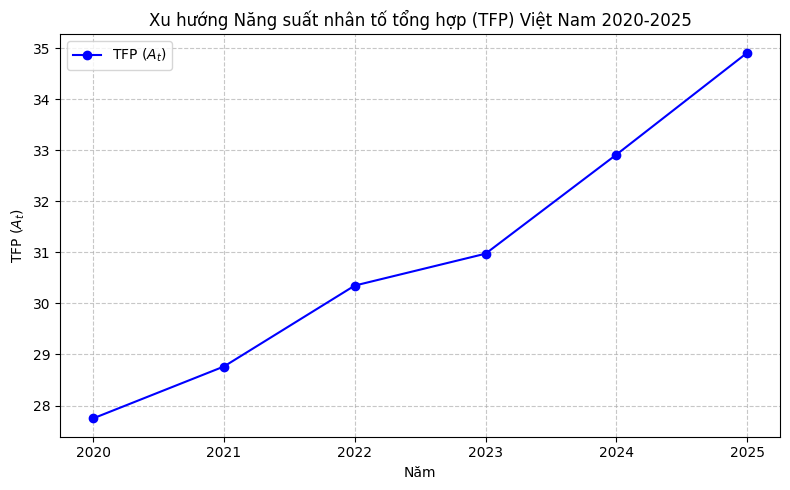

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Gán dữ liệu cho các mảng numpy dựa trên số liệu bảng 2020-2025
years = np.array([2020, 2021, 2022, 2023, 2024, 2025])
Y = np.array([8044.4, 8487.5, 9513.3, 10221.8, 11511.9, 12847.6])
K = np.array([16500, 17800, 19600, 21300, 23500, 25900])
L = np.array([53.6, 50.5, 51.7, 52.4, 52.9, 53.4])
D = np.array([12.0, 12.7, 14.3, 16.5, 18.3, 19.5])
AI = np.array([55.6, 60.2, 65.4, 67.0, 73.8, 80.1])
H = np.array([24.1, 26.1, 26.2, 27.0, 28.4, 29.2])

# Các hệ số co giãn đã cho
alpha, beta, gamma, delta, theta = 0.33, 0.42, 0.10, 0.08, 0.07

# Tính toán năng suất nhân tố tổng hợp A_t qua từng năm
A_t = Y / (K**alpha * L**beta * D**gamma * AI**delta * H**theta)

# In kết quả ra màn hình
print("Năng suất nhân tố tổng hợp (A_t) cho từng năm:")
for year, a_val in zip(years, A_t):
    print(f"Năm {year}: {a_val:.4f}")

# Vẽ đồ thị A_t theo năm
plt.figure(figsize=(8, 5))
plt.plot(years, A_t, marker='o', linestyle='-', color='b', label='TFP ($A_t$)')
plt.title('Xu hướng Năng suất nhân tố tổng hợp (TFP) Việt Nam 2020-2025')
plt.xlabel('Năm')
plt.ylabel('TFP ($A_t$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 1. Tính TFP trung bình của giai đoạn 2020-2025
A_mean = np.mean(A_t)
print(f"Năng suất nhân tố tổng hợp trung bình (A_mean): {A_mean:.4f}\n")

# 2. Tính sản lượng dự báo Y_hat (sử dụng A_mean làm hằng số)
Y_hat = A_mean * (K**alpha) * (L**beta) * (D**gamma) * (AI**delta) * (H**theta)

# Tạo DataFrame để so sánh Y thực tế và Y dự báo
df_compare = pd.DataFrame({
    'Năm': years,
    'Y_Thực_tế': Y,
    'Y_Dự_báo': Y_hat,
    'Sai_số_tuyệt_đối': np.abs(Y - Y_hat),
    'Sai_số_phần_trăm_(%)': np.abs((Y - Y_hat) / Y) * 100
})

print("Bảng so sánh Sản lượng thực tế và Sản lượng dự báo:")
print(df_compare.to_string(index=False))
print("-" * 50)

# 3. Tính và báo cáo chỉ số MAPE
mape = np.mean(np.abs((Y - Y_hat) / Y)) * 100
print(f"Chỉ số MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

Năng suất nhân tố tổng hợp trung bình (A_mean): 30.9444

Bảng so sánh Sản lượng thực tế và Sản lượng dự báo:
 Năm  Y_Thực_tế     Y_Dự_báo  Sai_số_tuyệt_đối  Sai_số_phần_trăm_(%)
2020     8044.4  8971.518400        927.118400             11.525016
2021     8487.5  9130.943269        643.443269              7.581069
2022     9513.3  9699.585680        186.285680              1.958160
2023    10221.8 10211.651615         10.148385              0.099282
2024    11511.9 10821.997183        689.902817              5.992954
2025    12847.6 11386.987664       1460.612336             11.368756
--------------------------------------------------
Chỉ số MAPE (Mean Absolute Percentage Error): 6.42%


Bảng phân rã tăng trưởng kinh tế Việt Nam 2020-2025:
--------------------------------------------------
          Yếu tố  Đóng góp (%)
Vốn vật chất (K)         31.78
    Lao động (L)         -0.34
      Số hóa (D)         10.37
Năng lực AI (AI)          6.24
 Nhân lực số (H)          2.87
         TFP (A)         49.08
--------------------------------------------------
Tổng cộng: 100%


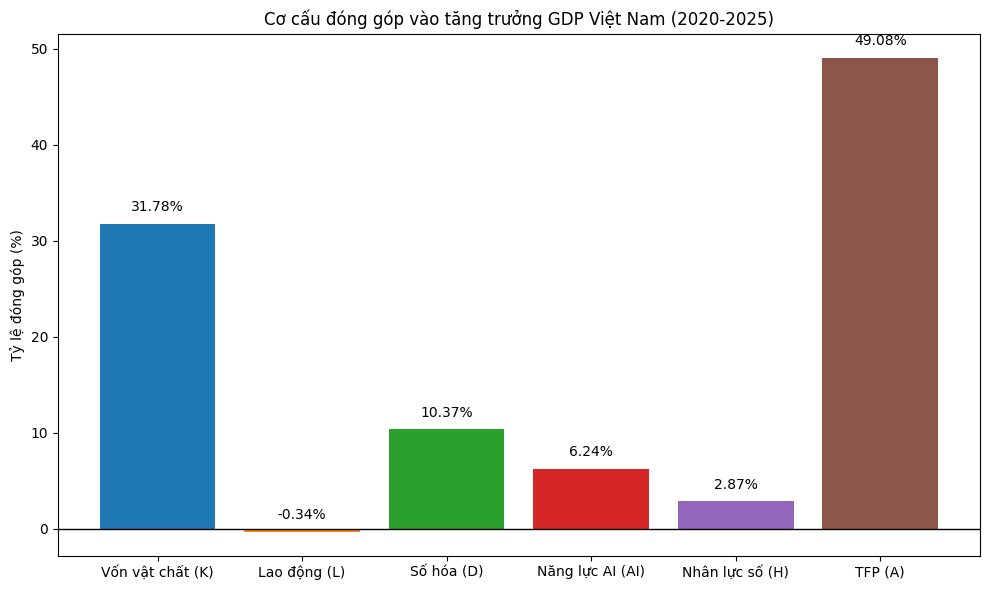

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Số năm của giai đoạn (2025 - 2020)
t = 5

# 1. Tính tốc độ tăng trưởng logarit bình quân hàng năm (đóng góp tuyệt đối)
g_Y = (np.log(Y[-1]) - np.log(Y[0])) / t

g_K = alpha * (np.log(K[-1]) - np.log(K[0])) / t
g_L = beta * (np.log(L[-1]) - np.log(L[0])) / t
g_D = gamma * (np.log(D[-1]) - np.log(D[0])) / t
g_AI = delta * (np.log(AI[-1]) - np.log(AI[0])) / t
g_H = theta * (np.log(H[-1]) - np.log(H[0])) / t

# TFP (A) là phần đóng góp còn lại (Residual)
g_A = g_Y - (g_K + g_L + g_D + g_AI + g_H)

# 2. Tính phần trăm (%) đóng góp của từng yếu tố vào tổng tăng trưởng GDP
contrib_pct = {
    'Vốn vật chất (K)': (g_K / g_Y) * 100,
    'Lao động (L)': (g_L / g_Y) * 100,
    'Số hóa (D)': (g_D / g_Y) * 100,
    'Năng lực AI (AI)': (g_AI / g_Y) * 100,
    'Nhân lực số (H)': (g_H / g_Y) * 100,
    'TFP (A)': (g_A / g_Y) * 100
}

# 3. Trình bày kết quả dưới dạng bảng
df_contrib = pd.DataFrame(list(contrib_pct.items()), columns=['Yếu tố', 'Đóng góp (%)'])
df_contrib['Đóng góp (%)'] = df_contrib['Đóng góp (%)'].round(2)

print("Bảng phân rã tăng trưởng kinh tế Việt Nam 2020-2025:")
print("-" * 50)
print(df_contrib.to_string(index=False))
print("-" * 50)
print(f"Tổng cộng: {df_contrib['Đóng góp (%)'].sum():.0f}%")

# 4. Trực quan hóa bằng biểu đồ cột (Bar Chart)
plt.figure(figsize=(10, 6))
bars = plt.bar(df_contrib['Yếu tố'], df_contrib['Đóng góp (%)'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontsize=10)

plt.title('Cơ cấu đóng góp vào tăng trưởng GDP Việt Nam (2020-2025)')
plt.ylabel('Tỷ lệ đóng góp (%)')
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Coefficients from the model
alpha, beta, gamma, delta, theta = 0.33, 0.42, 0.10, 0.08, 0.07

# 1. Base year 2025 data (from previous variables)
Y_2025 = Y[-1]
K_2025 = K[-1]
L_2025 = L[-1]
D_2025 = D[-1]
AI_2025 = AI[-1]
H_2025 = H[-1]
A_2025 = A_t[-1]

# 2. Forecasting parameters for 2030 (t = 5 years)
t = 5

# Growth assumptions
A_2030 = A_2025 * ((1 + 0.012) ** t)   # TFP +1.2%/year
K_2030 = K_2025 * ((1 + 0.06) ** t)    # Capital +6%/year
L_2030 = L_2025 * ((1 + 0.06) ** t)    # Labor +6%/year

# Targets
D_2030 = 30.0    # Digital economy target: 30%
AI_2030 = 100.0  # AI Capacity index target: 100
H_2030 = 35.0    # Digital Human Capital target: 35%

# 3. Forecast GDP for 2030
Y_2030 = A_2030 * (K_2030**alpha) * (L_2030**beta) * (D_2030**gamma) * (AI_2030**delta) * (H_2030**theta)

# 4. Results analysis
print(f"--- VIETNAM ECONOMIC FORECAST 2030 ---")
print(f"Forecast TFP (A_2030): {A_2030:.4f}")
print(f"Capital Stock (K_2030): {K_2030:.1f} trillion VND")
print(f"Labor Force (L_2030): {L_2030:.1f} million people")
print(f"-> Projected GDP 2030 (Y_2030): {Y_2030:.1f} trillion VND")

# Average growth rate 2026-2030
avg_growth = ((Y_2030 / Y_2025) ** (1/t) - 1) * 100
print(f"-> Avg Annual GDP Growth (2026-2030): {avg_growth:.2f}% / year")

--- VIETNAM ECONOMIC FORECAST 2030 ---
Forecast TFP (A_2030): 37.0593
Capital Stock (K_2030): 34660.0 trillion VND
Labor Force (L_2030): 71.5 million people
-> Projected GDP 2030 (Y_2030): 18262.0 trillion VND
-> Avg Annual GDP Growth (2026-2030): 7.29% / year
